
# 2. Анализ ключевых метрик интернет-магазина

## Цели:
- Расчет базовых бизнес-метрик
- Анализ динамики по времени
- Анализ по категориям и брендам
- Выявление топ-товаров и клиентов

In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')

In [3]:
# Настройка путей
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.metrics_calculator import MetricsCalculator

In [4]:
# Загрузка обработанных данных
print("ЗАГРУЗКА ДАННЫХ...")
processed_data_path = project_root / 'data' / 'processed' / 'merged_data.csv'

if processed_data_path.exists():
    df = pd.read_csv(processed_data_path)
    # Преобразуем дату обратно в datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    print(f"Загружено {len(df)} записей")
else:
    print("❌ Файл с обработанными данными не найден")
    print("Сначала запустите ноутбук 01_data_preprocessing.ipynb")

ЗАГРУЗКА ДАННЫХ...
Загружено 2366 записей


In [ ]:
# Инициализация калькулятора метрик
print("ИНИЦИАЛИЗАЦИЯ АНАЛИЗА МЕТРИК...")
try:
    metrics_calc = MetricsCalculator(df)
    print("✅ Анализатор успешно инициализирован")
except Exception as e:
    print(f"❌ Ошибка инициализации анализатора: {e}")

ИНИЦИАЛИЗАЦИЯ АНАЛИЗА МЕТРИК...


In [6]:
# 1. СВОДНЫЙ ОТЧЕТ
print("РАСЧЕТ СВОДНОГО ОТЧЕТА...")
summary = metrics_calc.get_summary_report()

РАСЧЕТ СВОДНОГО ОТЧЕТА...
СВОДНЫЙ ОТЧЕТ ПО МЕТРИКАМ

📊 БАЗОВЫЕ МЕТРИКИ:
  Общая выручка: 11,710,723 ₽
  Количество заказов: 2,350.0
  Уникальные клиенты: 861.0
  Средний чек: 4,983 ₽
  Общее количество товаров: 5,941.0
  Среднее количество товаров в заказе: 2.5
  Общая прибыль: 15,863,278 ₽
  Средняя прибыль на заказ: 6,750 ₽
  Средняя маржа: 72.7%
  Доля прибыльных заказов: 93.3%

📈 ВРЕМЕННЫЕ МЕТРИКИ (по месяцам):
  Период анализа: 2025-01 - 2025-09
  Средняя месячная выручка: 1,301,191 ₽
  Месяц с максимальной выручкой: 2025-05 (1,367,920 ₽)

🏷️ МЕТРИКИ ПО БРЕНДАМ:
  Топ бренд по выручке: KZDOO (8,534,704 ₽)


In [7]:
# 2. БАЗОВЫЕ МЕТРИКИ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ БАЗОВЫХ МЕТРИК")
print("="*60)

basic_metrics = metrics_calc.calculate_basic_metrics()
print("\nБазовые метрики:")
print(basic_metrics.to_string(index=False))


ДЕТАЛЬНЫЙ АНАЛИЗ БАЗОВЫХ МЕТРИК

Базовые метрики:
 revenue  orders  customers         aov  total_quantity  avg_items_per_order  total_profit  avg_profit_per_order  avg_margin  profitable_orders  profitable_orders_ratio
11710723    2350        861 4983.286383            5941             2.528085   15863278.27           6750.331179    0.727104               2207                 0.932798


In [8]:
# 3. ВРЕМЕННЫЕ МЕТРИКИ
print("\n" + "="*60)
print("АНАЛИЗ ДИНАМИКИ ПО ВРЕМЕНИ")
print("="*60)

# Метрики по месяцам
monthly_metrics = metrics_calc.calculate_time_series_metrics('M')
print("\nМетрики по месяцам:")
print(monthly_metrics.to_string(index=False))

# Метрики по неделям
weekly_metrics = metrics_calc.calculate_time_series_metrics('W')
print("\nМетрики по неделям (первые 10):")
print(weekly_metrics.head(10).to_string(index=False))


АНАЛИЗ ДИНАМИКИ ПО ВРЕМЕНИ

Метрики по месяцам:
 revenue  orders  customers         aov  total_quantity  avg_items_per_order  total_profit  avg_profit_per_order  avg_margin  profitable_orders  profitable_orders_ratio  period
 1349095     253        228 5332.391304             684             2.703557    2059366.85           8139.789921    0.777011                239                 0.940945 2025-01
 1237910     252        226 4912.341270             621             2.464286    1619339.52           6425.950476    0.711548                242                 0.952756 2025-02
 1157706     245        218 4725.330612             622             2.538776    1639966.74           6693.741796    0.727755                228                 0.926829 2025-03
 1366788     279        240 4898.881720             671             2.405018    1732142.90           6208.397491    0.683260                255                 0.907473 2025-04
 1367920     267        214 5123.295880             702           

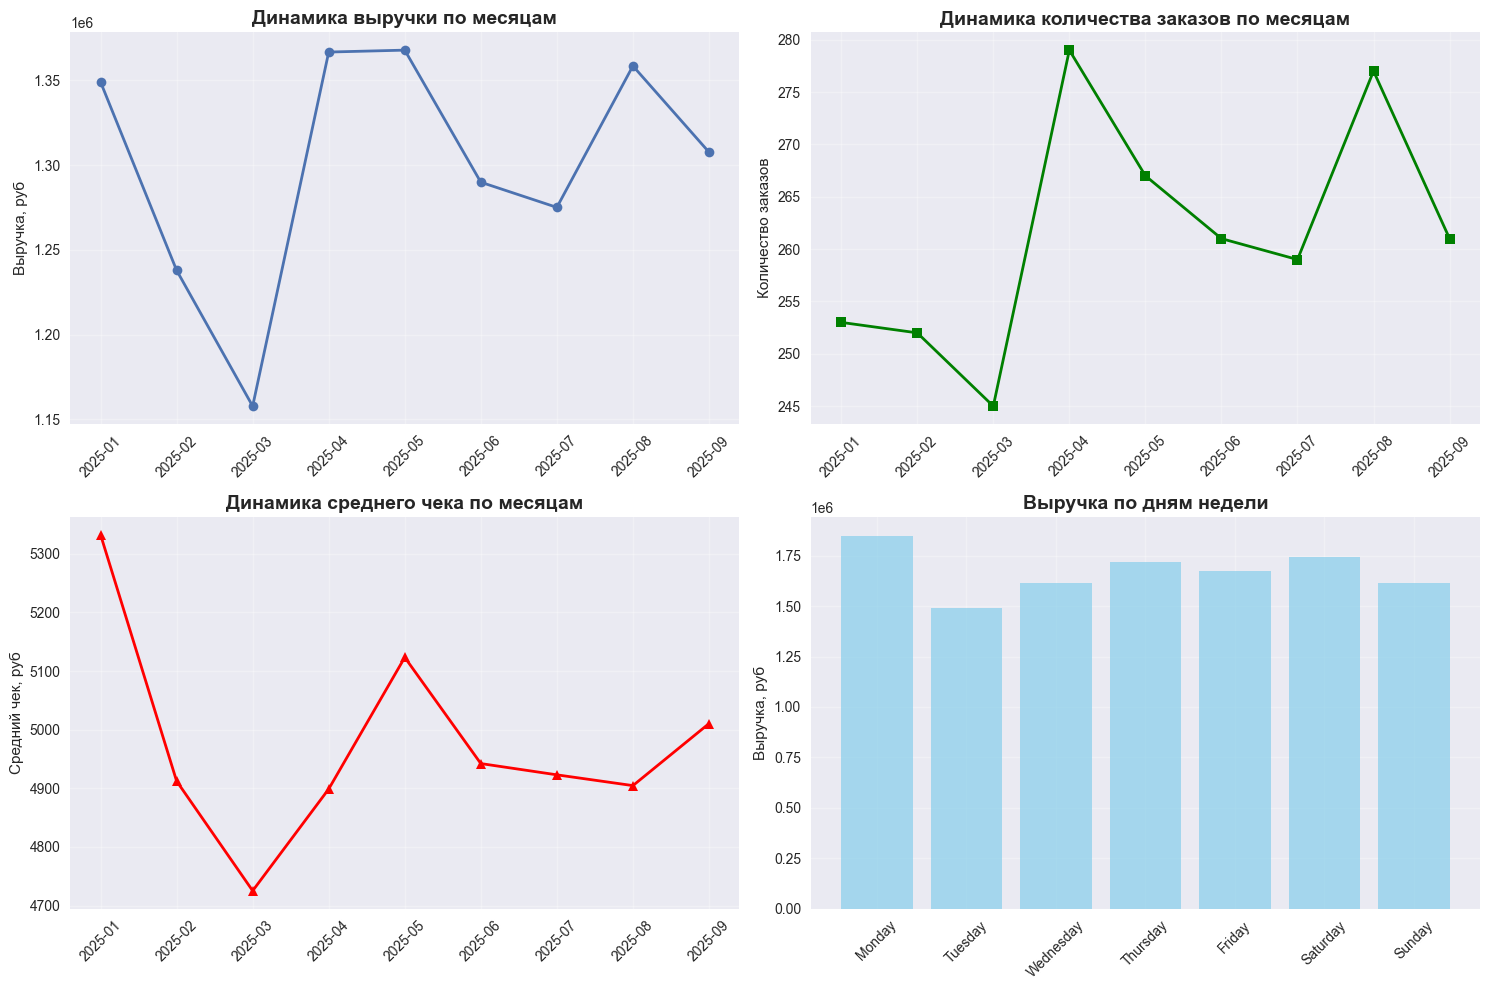

In [9]:
# 4. ВИЗУАЛИЗАЦИЯ ДИНАМИКИ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Динамика выручки по месяцам
if not monthly_metrics.empty:
    axes[0,0].plot(monthly_metrics['period'], monthly_metrics['revenue'], marker='o', linewidth=2)
    axes[0,0].set_title('Динамика выручки по месяцам', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Выручка, руб')
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,0].grid(True, alpha=0.3)

# Динамика количества заказов
if not monthly_metrics.empty:
    axes[0,1].plot(monthly_metrics['period'], monthly_metrics['orders'], marker='s', color='green', linewidth=2)
    axes[0,1].set_title('Динамика количества заказов по месяцам', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('Количество заказов')
    axes[0,1].tick_params(axis='x', rotation=45)
    axes[0,1].grid(True, alpha=0.3)

# Динамика среднего чека
if not monthly_metrics.empty:
    axes[1,0].plot(monthly_metrics['period'], monthly_metrics['aov'], marker='^', color='red', linewidth=2)
    axes[1,0].set_title('Динамика среднего чека по месяцам', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Средний чек, руб')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(True, alpha=0.3)

# Распределение выручки по дням недели
if 'date' in df.columns:
    df['day_of_week'] = df['date'].dt.day_name()
    daily_revenue = df.groupby('day_of_week')['revenue'].sum()
    # Упорядочим дни недели
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    daily_revenue = daily_revenue.reindex(days_order)
    
    axes[1,1].bar(daily_revenue.index, daily_revenue.values, color='skyblue', alpha=0.7)
    axes[1,1].set_title('Выручка по дням недели', fontsize=14, fontweight='bold')
    axes[1,1].set_ylabel('Выручка, руб')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/02_time_series_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# 5. АНАЛИЗ ПО КАТЕГОРИЯМ
print("\n" + "="*60)
print("АНАЛИЗ ПО КАТЕГОРИЯМ И БРЕНДАМ")
print("="*60)

category_metrics = metrics_calc.calculate_category_metrics()

# Анализ по брендам
if 'by_brand' in category_metrics:
    brand_metrics = category_metrics['by_brand']
    print("\nТоп-10 брендов по выручке:")
    top_brands = brand_metrics.nlargest(10, 'revenue')[['Бренд', 'revenue', 'orders', 'aov', 'avg_margin']]
    print(top_brands.to_string(index=False))

# Анализ по категориям
if 'by_category' in category_metrics:
    category_metrics_df = category_metrics['by_category']
    print("\nТоп-5 категорий по выручке:")
    top_categories = category_metrics_df.nlargest(5, 'revenue')[['Категория', 'revenue', 'orders', 'aov']]
    print(top_categories.to_string(index=False))


АНАЛИЗ ПО КАТЕГОРИЯМ И БРЕНДАМ

Топ-10 брендов по выручке:
     Бренд  revenue  orders          aov  avg_margin
     KZDOO  8534704    1554  5492.087516    0.748881
  KEEPHONE  1743949     341  5114.219941    0.737507
     K-DOO   601024     137  4387.036496    0.685646
   Robiton   296250     135  2194.444444    0.610979
Неизвестно   206660      20 10333.000000    0.727121
     REMAX   115266      84  1372.214286    0.649680
Нет бренда    76230      36  2117.500000    0.636609
     Varta    69420      25  2776.800000    0.724571
    Raigor    31080       6  5180.000000    0.830997
    Renata    25920      16  1620.000000    0.702346

Топ-5 категорий по выручке:
               Категория  revenue  orders         aov
                   Чехлы 11187377    2088 5357.939176
Батарейки и аккумуляторы   401810     186 2160.268817
Защитные пленки и стекла   115266      84 1372.214286
    Кабели и переходники     6270       6 1045.000000


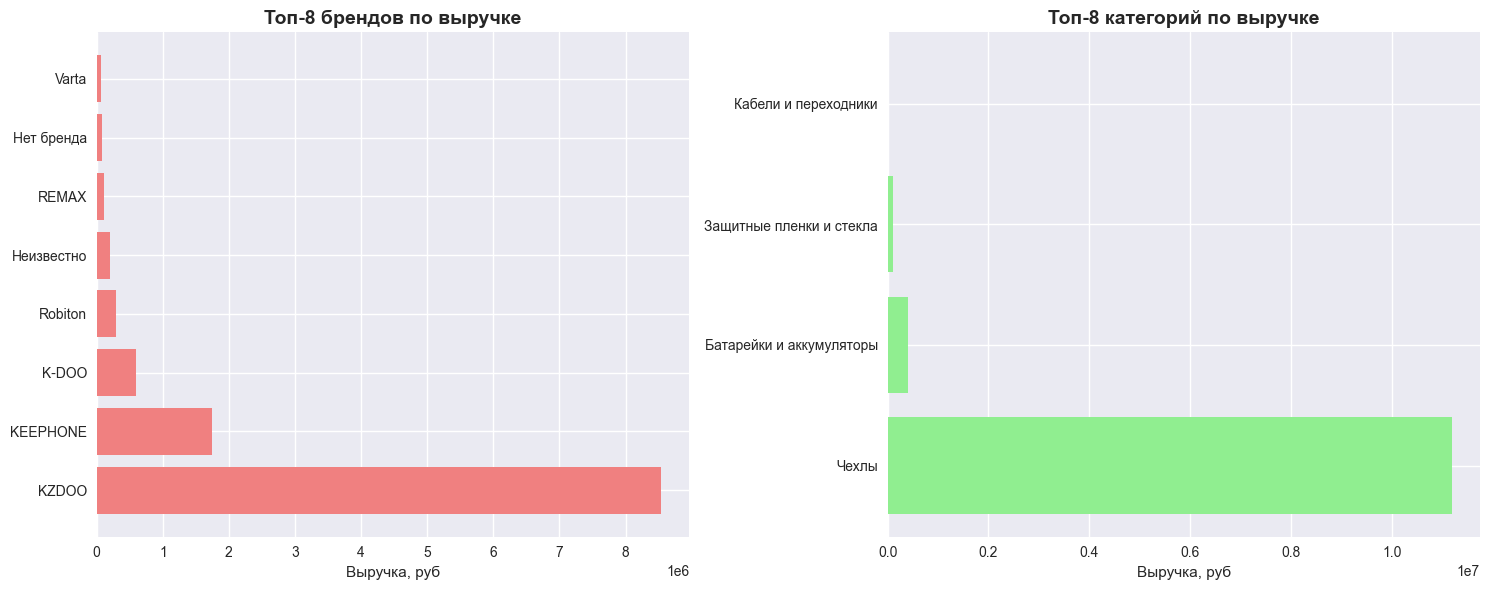

In [11]:
# 6. ВИЗУАЛИЗАЦИЯ ПО КАТЕГОРИЯМ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Топ бренды по выручке
if 'by_brand' in category_metrics:
    top_brands_viz = category_metrics['by_brand'].nlargest(8, 'revenue')
    axes[0].barh(top_brands_viz['Бренд'], top_brands_viz['revenue'], color='lightcoral')
    axes[0].set_title('Топ-8 брендов по выручке', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Выручка, руб')

# Топ категории по выручке
if 'by_category' in category_metrics:
    top_categories_viz = category_metrics['by_category'].nlargest(8, 'revenue')
    axes[1].barh(top_categories_viz['Категория'], top_categories_viz['revenue'], color='lightgreen')
    axes[1].set_title('Топ-8 категорий по выручке', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Выручка, руб')

plt.tight_layout()
plt.savefig('../reports/figures/02_category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# 7. АНАЛИЗ ТОВАРОВ
print("\n" + "="*60)
print("АНАЛИЗ ТОВАРОВ")
print("="*60)

top_products = metrics_calc.calculate_product_metrics(top_n=15)
if not top_products.empty:
    print("Топ-15 товаров по выручке:")
    display_cols = ['sku', 'revenue', 'orders', 'aov', 'avg_margin']
    display_cols = [col for col in display_cols if col in top_products.columns]
    print(top_products[display_cols].to_string(index=False))


АНАЛИЗ ТОВАРОВ
Топ-15 товаров по выручке:
              sku  revenue  orders     aov  avg_margin
   FFF_Clear_4303    99900      10  9990.0    0.809371
    HHH_Pink_2327    95040       9 10560.0    0.662995
  FFF_Purple_9422    88800       8 11100.0    0.657354
   BBB_White_3663    77700       7 11100.0    0.505521
    CCC_Pink_8383    66600       6 11100.0    0.835811
FFF_Titanium_1822    55500       5 11100.0    1.000000
   FFF_Black_3829    55500       5 11100.0    0.815495
   CCC_Green_7311    55500       5 11100.0    0.617387
   CCC_Green_1403    55500       5 11100.0    0.984450
  AAA_Purple_3399    54796       7  7828.0    0.874059
    BBB_Blue_8761    51800      10  5180.0    0.868602
   BBB_Green_2236    48400       8  6050.0    0.755217
   AAA_White_5168    47960       4 11990.0    0.978303
    GGG_Blue_7759    45900       5  9180.0    0.775795
   BBB_Green_8505    45900       5  9180.0    0.643913


In [13]:
# 8. АНАЛИЗ КЛИЕНТОВ
print("\n" + "="*60)
print("АНАЛИЗ КЛИЕНТОВ")
print("="*60)

customer_metrics = metrics_calc.calculate_customer_metrics()
if not customer_metrics.empty:
    print("Статистика по клиентам:")
    print(f"Всего уникальных клиентов: {len(customer_metrics)}")
    print(f"Среднее количество заказов на клиента: {customer_metrics['orders'].mean():.1f}")
    print(f"Медиана выручки на клиента: {customer_metrics['total_revenue'].median():.0f} ₽")
    
    print("\nТоп-10 клиентов по выручке:")
    top_customers = customer_metrics.nlargest(10, 'total_revenue')[['customer_id', 'orders', 'total_revenue', 'avg_order_value']]
    print(top_customers.to_string(index=False))



АНАЛИЗ КЛИЕНТОВ
Статистика по клиентам:
Всего уникальных клиентов: 861
Среднее количество заказов на клиента: 2.7
Медиана выручки на клиента: 10470 ₽

Топ-10 клиентов по выручке:
 customer_id  orders  total_revenue  avg_order_value
    93626225      10          99900           9990.0
    70326795       8          88800          11100.0
    55570580       7          77700          11100.0
    60736622       4          75040          18760.0
    48742299       6          66600          11100.0
    42669478       5          55500          11100.0
    71643669       5          55500          11100.0
    80262000       5          55500          11100.0
    99453640       5          55500          11100.0
    70160612       7          54796           7828.0


In [14]:
# 9. СОХРАНЕНИЕ ОТЧЕТА
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

# Создаем папку для отчетов
report_path = project_root / 'reports' / 'metrics'
report_path.mkdir(parents=True, exist_ok=True)

# Сохраняем основные метрики
if not monthly_metrics.empty:
    monthly_metrics.to_csv(report_path / 'monthly_metrics.csv', index=False)
    print("✓ Сохранены месячные метрики")

if 'by_brand' in category_metrics:
    category_metrics['by_brand'].to_csv(report_path / 'brand_metrics.csv', index=False)
    print("✓ Сохранены метрики по брендам")

if not top_products.empty:
    top_products.to_csv(report_path / 'top_products.csv', index=False)
    print("✓ Сохранены метрики по товарам")

if not customer_metrics.empty:
    customer_metrics.to_csv(report_path / 'customer_metrics.csv', index=False)
    print("✓ Сохранены метрики по клиентам")


print("\n✅ АНАЛИЗ МЕТРИК ЗАВЕРШЕН!")
print("📊 Созданы визуализации в /reports/figures/")
print("📁 Сохранены данные в /reports/metrics/")


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
✓ Сохранены месячные метрики
✓ Сохранены метрики по брендам
✓ Сохранены метрики по товарам
✓ Сохранены метрики по клиентам

✅ АНАЛИЗ МЕТРИК ЗАВЕРШЕН!
📊 Созданы визуализации в /reports/figures/
📁 Сохранены данные в /reports/metrics/
